# 01. Data Acquisition & Exploratory Data Analysis
Acquisition of 5-year adjusted close prices for 10 high-capitalization IDX assets.
Objective: Characterization of return distributions, asset correlations, and idiosyncratic risk profiles prior to optimization.

In [1]:
import sys; sys.path.insert(0, '..')
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

import pandas as pd
import numpy as np
from dotenv import load_dotenv
load_dotenv()

from src.data.fetcher import StockDataFetcher
from src.portfolio.metrics import (
    TRADING_DAYS_PER_YEAR, RISK_FREE_RATE_ANNUAL, DEFAULT_TICKERS,
    DEFAULT_START_DATE, DEFAULT_END_DATE
)
from src.visualization.plots import (
    plot_correlation_heatmap, plot_cumulative_returns, plot_return_distribution
)

SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

## 1. Data Collection

In [2]:
fetcher = StockDataFetcher(DEFAULT_TICKERS, DEFAULT_START_DATE, DEFAULT_END_DATE)
prices = fetcher.fetch()
log_returns = fetcher.to_log_returns(prices)

print(f'Tickers:       {list(prices.columns)}')
print(f'Date range:    {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Trading days:  {len(prices)}')
print(f'Missing values: {prices.isna().sum().sum()}')

INFO: Loading from cache: data/cache/4c9b5bec659c75c231b2df3b19a3bf90.csv


Tickers:       ['ASII.JK', 'BBCA.JK', 'BBRI.JK', 'BMRI.JK', 'EXCL.JK', 'ICBP.JK', 'INDF.JK', 'KLBF.JK', 'TLKM.JK', 'UNVR.JK']
Date range:    2019-01-01 → 2024-12-30
Trading days:  1469
Missing values: 0


In [3]:
prices.head().style.format('{:.0f}').set_caption('Adjusted Close Prices (IDR)')

,ASII.JK,BBCA.JK,BBRI.JK,BMRI.JK,EXCL.JK,ICBP.JK,INDF.JK,KLBF.JK,TLKM.JK,UNVR.JK
2019-01-01 00:00:00,5127,4254,2148,2324,1657,9023,5712,1322,2635,6983
2019-01-02 00:00:00,5112,4287,2119,2308,1657,8980,5578,1327,2621,7137
2019-01-03 00:00:00,5221,4237,2125,2261,1690,9131,5731,1340,2628,7307
2019-01-04 00:00:00,5205,4258,2148,2348,1707,9153,5693,1366,2607,7353
2019-01-07 00:00:00,5081,4291,2148,2340,1791,8937,5693,1388,2649,7476


## 2. Normalized Price Performance

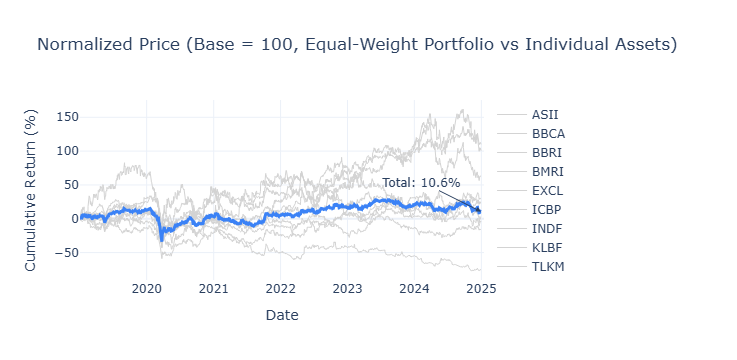

In [4]:
n_assets = len(prices.columns)
equal_weights = np.array([1/n_assets] * n_assets)
fig = plot_cumulative_returns(prices, equal_weights, list(prices.columns))
fig.update_layout(title='Normalized Price (Base = 100, Equal-Weight Portfolio vs Individual Assets)')
fig.show()

### Interpretation
- Most assets show a recovery trend post-2020.
- The equal-weight portfolio provides a smoother return profile compared to most individual volatile assets.
- Significant dispersion is visible among individual ticker performances.

## 3. Summary Statistics

In [5]:
stats = fetcher.get_summary_stats(log_returns)
stats_display = stats.copy()
stats_display[['annual_return', 'annual_volatility']] *= 100
stats_display = stats_display.round(2)
stats_display.columns = ['Ann. Return (%)', 'Ann. Volatility (%)', 'Sharpe Ratio', 'Skewness', 'Kurtosis']
stats_display.sort_values('Sharpe Ratio', ascending=False).style\
    .background_gradient(subset=['Sharpe Ratio'], cmap='RdYlGn')\
    .format(precision=2)\
    .set_caption('Individual Asset Statistics (2019–2024)')

,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Skewness,Kurtosis
BBCA.JK,12.74,24.07,0.27,0.73,11.16
BMRI.JK,11.95,32.78,0.17,-0.03,5.37
BBRI.JK,8.34,31.55,0.07,0.59,7.41
INDF.JK,4.53,27.44,-0.06,0.40,11.15
EXCL.JK,3.59,40.86,-0.07,0.91,6.00
ICBP.JK,3.57,27.03,-0.10,0.18,6.60
KLBF.JK,0.08,32.39,-0.19,0.76,5.92
TLKM.JK,-0.82,28.88,-0.24,0.45,4.15
ASII.JK,-3.04,31.48,-0.30,0.13,3.48
UNVR.JK,-23.58,33.12,-0.90,0.90,8.36


## 4. Return Distributions

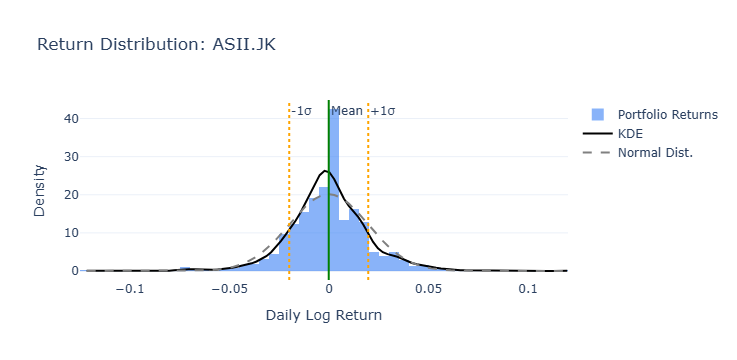

In [6]:
# Plotting for the first asset as an example
first_asset_weights = np.zeros(len(prices.columns))
first_asset_weights[0] = 1.0
fig = plot_return_distribution(log_returns, first_asset_weights)
fig.update_layout(title=f'Return Distribution: {prices.columns[0]}')
fig.show()

### Note on Normality
Many financial assets exhibit fat tails (kurtosis > 3). If the kurtosis is significantly high, the normal distribution assumption used in parametric VaR might underestimate extreme tail risks.

## 5. Correlation Analysis

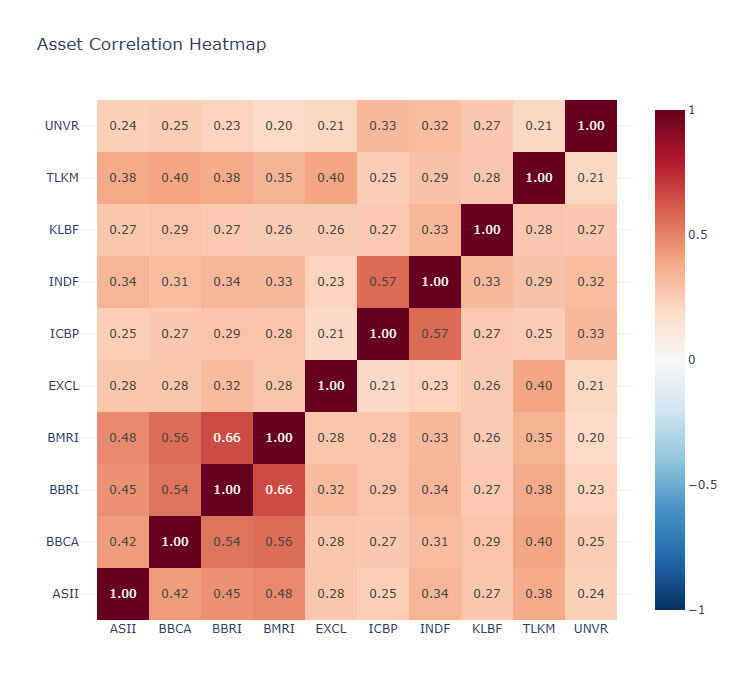

In [7]:
fig = plot_correlation_heatmap(log_returns)
fig.show()

### Interpretation
- Strong correlations are observed within the banking sector (e.g., BBCA, BBRI, BMRI).
- Lower correlations between different sectors (e.g., Telecom vs Consumer Staples) offer better diversification benefits.

## 6. Key Findings
- Highest Sharpe individual asset: BBCA.JK (0.27)
- Most volatile asset: EXCL.JK (40.86%)
- Lowest correlation pair (diversification opportunity): BMRI.JK and UNVR.JK (0.20)
- Average pairwise correlation: 0.33
- Period: 2019-2024 includes the COVID-19 crash (visible in 2020) and subsequent sectoral recovery.